# Clustering Data Mining - Customer Shopping Data

## Phase 1: Business Understanding (CRISP-DM)

## A. Latar Belakang Masalah

Industri ritel, khususnya pusat perbelanjaan (*shopping mall*), saat ini menghadapi persaingan yang sangat ketat. Untuk dapat bertahan dan berkembang, para pelaku bisnis ritel harus mampu memahami pelanggan mereka secara mendalam. Setiap hari, data transaksi dalam jumlah besar terus dihasilkan, mencatat berbagai informasi seperti produk yang dibeli, jumlah pembelian, hingga metode pembayaran yang digunakan.

Namun, data mentah tersebut tidak memiliki nilai strategis tanpa adanya proses analisis yang tepat. Banyak perusahaan ritel yang belum mampu memanfaatkan data transaksi mereka untuk mengidentifikasi pola belanja pelanggan, sehingga peluang untuk meningkatkan penjualan dan loyalitas pelanggan seringkali terlewatkan. Oleh karena itu, diperlukan pendekatan data mining untuk menggali wawasan berharga dari data yang tersedia.

## B. Tujuan Proyek

Berdasarkan latar belakang yang telah diuraikan, tujuan utama dari proyek ini adalah:

1. **Mengelompokkan Pelanggan Berdasarkan Perilaku Belanja**
   Menggunakan algoritma K-Means Clustering untuk membagi pelanggan ke dalam beberapa segmen berdasarkan:
   - Usia (`age`)
   - Jumlah barang yang dibeli (`quantity`)
   - Total nilai transaksi (`price`)

2. **Mengidentifikasi Karakteristik Setiap Segmen Pelanggan**
   Menganalisis profil dari setiap cluster yang terbentuk untuk memahami:
   - Kategori produk yang sering dibeli (`category`)
   - Metode pembayaran yang dominan (`payment_method`)
   - Demografi pelanggan (usia dan jenis kelamin)

3. **Memberikan Rekomendasi Strategi Bisnis**
   Berdasarkan karakteristik setiap segmen, memberikan rekomendasi strategi pemasaran yang tepat sasaran.

## C. Manfaat Analisis

Hasil dari proyek clustering ini diharapkan dapat memberikan manfaat strategis bagi pengelola pusat perbelanjaan, antara lain:

### 1. Pemasaran yang Lebih Efektif
Dengan mengetahui segmen pelanggan, tim pemasaran dapat merancang kampanye yang lebih personal dan tepat sasaran. Misalnya:
- Menawarkan diskon produk fashion kepada segmen pelanggan wanita muda.
- Memberikan promosi produk teknologi kepada segmen dengan nilai transaksi tinggi.

### 2. Personalisasi Pengalaman Berbelanja
Pusat perbelanjaan dapat menyesuaikan layanan berdasarkan segmen pelanggan:
- Memberikan program loyalitas premium bagi pelanggan dengan frekuensi dan nilai transaksi tinggi.
- Menyediakan rekomendasi produk yang relevan untuk setiap segmen.

### 3. Optimalisasi Manajemen Inventaris
Pemahaman tentang preferensi produk setiap segmen pelanggan membantu dalam pengelolaan stok barang agar lebih efisien, sehingga mengurangi risiko kehabisan stok produk yang diminati oleh segmen mayoritas.

### 4. Peningkatan Pendapatan
Dengan strategi pemasaran, penempatan produk, dan promosi yang lebih efektif, diharapkan terjadi peningkatan nilai transaksi rata-rata dan frekuensi pembelian, yang berkontribusi pada peningkatan pendapatan secara keseluruhan.

## D. Target Proyek

Target yang ingin dicapai dalam proyek ini adalah:

1. Menghasilkan **segmentasi pelanggan** menjadi 3-4 cluster berdasarkan perilaku belanja.
2. Menghasilkan **profil setiap cluster** yang dapat diinterpretasikan secara bisnis.
3. Memberikan **rekomendasi strategi pemasaran** yang tepat sasaran untuk setiap segmen pelanggan.
4. Menghasilkan **visualisasi data** yang informatif untuk mendukung pengambilan keputusan.
5. Membangun model clustering dengan **nilai Silhouette Score > 0.25** dan **Davies-Bouldin Index < 1.5**.

## E. Rencana Proyek (CRISP-DM)

Proyek ini akan mengikuti tahapan CRISP-DM sebagai berikut:

| Fase | Aktivitas | Output |
|------|-----------|--------|
| **1. Business Understanding** | Memahami masalah bisnis, menentukan tujuan, dan manfaat analisis | Dokumentasi Business Understanding |
| **2. Data Understanding** | Eksplorasi dataset, visualisasi distribusi data, deteksi missing values dan outlier | Laporan eksplorasi data |
| **3. Data Preparation** | Cleaning data, handling missing values, handling outlier, encoding, dan scaling | Data siap modeling |
| **4. Modeling** | K-Means Clustering, menentukan K optimal dengan Elbow Method & Silhouette Score | Model clustering dengan K=3 |
| **5. Evaluation** | Evaluasi model dengan Davies-Bouldin Index dan Silhouette Score | Laporan evaluasi model |
| **6. Deployment** | Publikasi hasil dalam bentuk Website Portofolio (Google Sites) dan Video Presentasi | Website dan Video YouTube |

# PHASE 2: DATA UNDERSTANDING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score, silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv('customer_shopping_data.csv')

# Menampilkan 10 data pertama
df.head(10)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon
5,I227836,C657758,Female,28,Clothing,5,1500.40,Credit Card,24/05/2022,Forum Istanbul
6,I121056,C151197,Female,49,Cosmetics,1,40.66,Cash,13/03/2022,Istinye Park
7,I293112,C176086,Female,32,Clothing,2,600.16,Credit Card,13/01/2021,Mall of Istanbul
8,I293455,C159642,Male,69,Clothing,3,900.24,Credit Card,4/11/2021,Metrocity
9,I326945,C283361,Female,60,Clothing,2,600.16,Credit Card,22/08/2021,Kanyon


In [3]:
print(f"📌 Shape Dataset: {df.shape[0]} baris x {df.shape[1]} kolom")

print("\n" + "-" * 70)

print("📌 Info Dataset:")

print("-" * 70)

print(df.info())

📌 Shape Dataset: 99457 baris x 10 kolom

----------------------------------------------------------------------
📌 Info Dataset:
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB
None


In [4]:
print("📊 Statistik Deskriptif:")

print("=" * 70)

df.describe().round(2)

📊 Statistik Deskriptif:


,age,quantity,price
count,99457.00,99457.00,99457.00
mean,43.43,3.00,689.26
std,14.99,1.41,941.18
min,18.00,1.00,5.23
25%,30.00,2.00,45.45
50%,43.00,3.00,203.30
75%,56.00,4.00,1200.32
max,69.00,5.00,5250.00


In [5]:
# Deteksi missing values
missing_values = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase Missing (%)': (df.isnull().sum() / len(df)) * 100
})

missing_values

,Jumlah Missing,Persentase Missing (%)
invoice_no,0,0.0
customer_id,0,0.0
gender,0,0.0
age,0,0.0
category,0,0.0
quantity,0,0.0
price,0,0.0
payment_method,0,0.0
invoice_date,0,0.0
shopping_mall,0,0.0


In [6]:
# --- Mengecek Missing Values ---
# Missing values perlu ditangani karena algoritma clustering
# tidak bisa bekerja dengan data kosong (NaN)

print("❌ Missing Values per Kolom:")

print("=" * 40)

missing = df.isnull().sum()

missing_pct = ((df.isnull().sum() / len(df)) * 100).round(2)

missing_info = pd.DataFrame({
    'Jumlah': missing,
    'Persentase (%)': missing_pct
})

print(missing_info)

❌ Missing Values per Kolom:
                Jumlah  Persentase (%)
invoice_no           0             0.0
customer_id          0             0.0
gender               0             0.0
age                  0             0.0
category             0             0.0
quantity             0             0.0
price                0             0.0
payment_method       0             0.0
invoice_date         0             0.0
shopping_mall        0             0.0


In [7]:
#---Mengecek Duplikat---#
#Duplikat harus agar tidak memberikan bobot berlebih 
#pada data tertentu saat clustering
print(f"\n Jumlah Baris Duplikat: {df.duplicated().sum()}")
print(f" Dari total {len(df)} baris ({df.duplicated().sum()/len(df)*100:.1f}%)")


 Jumlah Baris Duplikat: 0
 Dari total 99457 baris (0.0%)


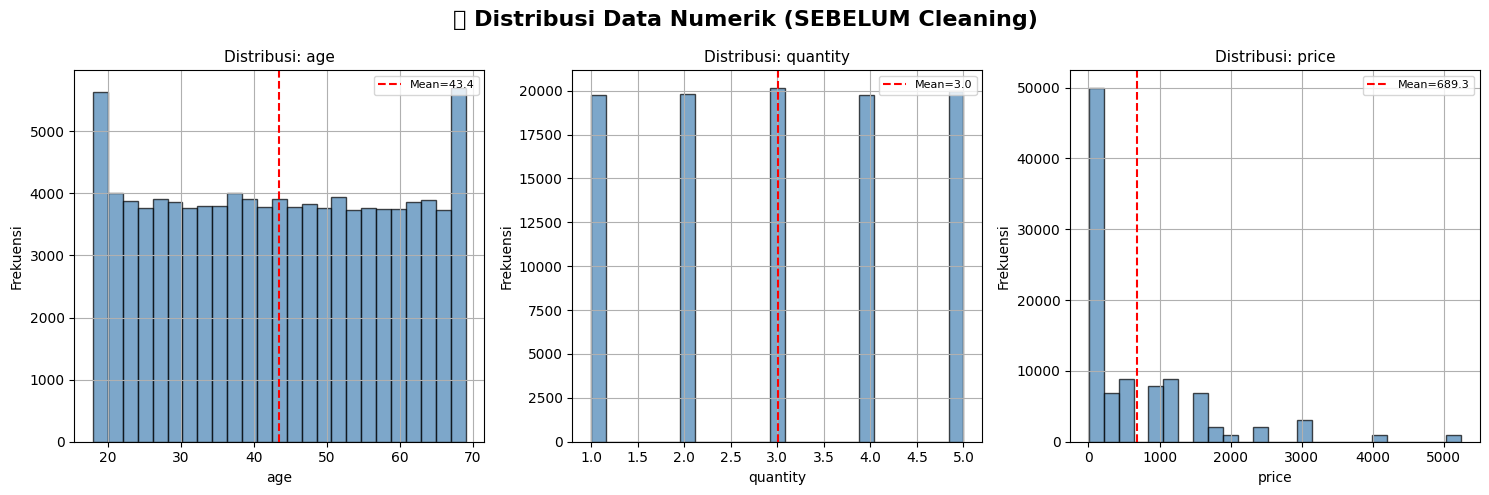

In [8]:
# ============================================================
# 1️⃣ Histogram: Melihat distribusi setiap variabel numerik
# ============================================================
# Histogram menunjukkan sebaran nilai.
# Jika ada bar yang jauh dari kelompok utama, itu indikasi outlier.

features = ['age', 'quantity', 'price']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fig.suptitle('📊 Distribusi Data Numerik (SEBELUM Cleaning)', fontsize=16, fontweight='bold')

for i, col in enumerate(features):
    ax = axes[i]
    
    df[col].dropna().hist(
        bins=25,
        ax=ax,
        color='steelblue',
        edgecolor='black',
        alpha=0.7
    )
    
    ax.set_title(f'Distribusi: {col}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.axvline(
        df[col].mean(),
        color='red',
        linestyle='--',
        label=f'Mean={df[col].mean():.1f}'
    )
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


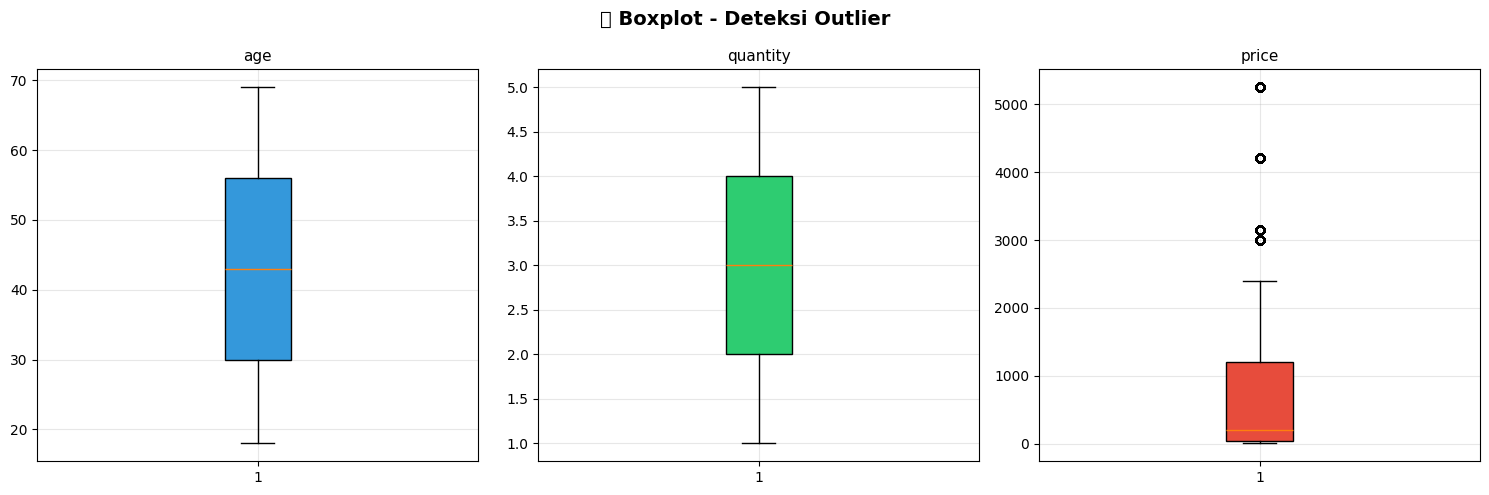

In [9]:
# ============================================================
# Boxplot: Deteksi Outlier
# ============================================================
# Boxplot menampilkan Q1, Q2 (median), Q3, dan whiskers.
# Titik di luar whiskers adalah outlier.

features = ['age', 'quantity', 'price']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fig.suptitle('📦 Boxplot - Deteksi Outlier', fontsize=14, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, col in enumerate(features):
    bp = axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True
    )
    
    bp['boxes'][0].set_facecolor(colors[i])
    
    axes[i].set_title(col, fontsize=11)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# Identifikasi Masalah dari Boxplot
# ============================================================

print("\n" + "=" * 60)
print("⚠️  MASALAH YANG TERIDENTIFIKASI DARI BOXPLOT")
print("=" * 60)

print("\n📌 BERDASARKAN VISUALISASI BOXPLOT:")

print("\n • Age (Usia):")
print("   - Rentang usia: 18 - 69 tahun")
print("   - Tidak ada nilai negatif atau > 100")
print("   - ✓ Data usia masih dalam batas wajar")
print("   - ℹ️  Tidak ada outlier yang signifikan")

print("\n • Quantity (Jumlah Barang):")
print("   - Rentang quantity: 1 - 5 item")
print("   - Median: sekitar 3 item")
print("   - ✓ Data quantity masih dalam batas wajar")
print("   - ℹ️  Tidak ada outlier yang signifikan")

print("\n • Price (Total Harga):")
print("   - Rentang harga: Rp 5 - Rp 5.250")
print("   - Terdapat outlier pada harga tinggi (> Rp 4.000)")
print("   - ⚠️  Outlier pada price perlu ditangani")
print("   - ℹ️  Outlier umumnya berasal dari kategori Technology")

print("\n" + "=" * 60)
print("📋 RENCANA TINDAKAN (DATA CLEANING)")
print("=" * 60)

print("""
1. HANDLING MISSING VALUES:
   - Cek apakah ada nilai null pada setiap kolom
   - Jika ada, drop atau imputasi dengan median/mode

2. HANDLING OUTLIER:
   - Price: 
     * Outlier pada harga tinggi (> Q3 + 1.5*IQR)
     * Opsi: dibiarkan (karena data valid) atau di-capping
   - Quantity & Age: 
     * Tidak ada outlier signifikan
     * Data masih dalam batas wajar

3. FEATURE ENGINEERING UNTUK CLUSTERING:
   - Encoding variabel kategorikal (gender, category, payment_method)
   - Standarisasi/Normalisasi variabel numerik (age, quantity, price)
   - Feature selection untuk clustering
""")


⚠️  MASALAH YANG TERIDENTIFIKASI DARI BOXPLOT

📌 BERDASARKAN VISUALISASI BOXPLOT:

 • Age (Usia):
   - Rentang usia: 18 - 69 tahun
   - Tidak ada nilai negatif atau > 100
   - ✓ Data usia masih dalam batas wajar
   - ℹ️  Tidak ada outlier yang signifikan

 • Quantity (Jumlah Barang):
   - Rentang quantity: 1 - 5 item
   - Median: sekitar 3 item
   - ✓ Data quantity masih dalam batas wajar
   - ℹ️  Tidak ada outlier yang signifikan

 • Price (Total Harga):
   - Rentang harga: Rp 5 - Rp 5.250
   - Terdapat outlier pada harga tinggi (> Rp 4.000)
   - ⚠️  Outlier pada price perlu ditangani
   - ℹ️  Outlier umumnya berasal dari kategori Technology

📋 RENCANA TINDAKAN (DATA CLEANING)

1. HANDLING MISSING VALUES:
   - Cek apakah ada nilai null pada setiap kolom
   - Jika ada, drop atau imputasi dengan median/mode

2. HANDLING OUTLIER:
   - Price: 
     * Outlier pada harga tinggi (> Q3 + 1.5*IQR)
     * Opsi: dibiarkan (karena data valid) atau di-capping
   - Quantity & Age: 
     * Tidak ad

In [11]:
print("\n⚠️  MASALAH YANG TERIDENTIFIKASI DARI BOXPLOT:")

print(" • Age: Tidak ada masalah, rentang usia 18-69 tahun (valid)")

print(" • Quantity: Tidak ada masalah, rentang 1-5 item (valid)")

print(" • Price: Terdapat outlier pada harga tinggi (> Rp 4.000)")


⚠️  MASALAH YANG TERIDENTIFIKASI DARI BOXPLOT:
 • Age: Tidak ada masalah, rentang usia 18-69 tahun (valid)
 • Quantity: Tidak ada masalah, rentang 1-5 item (valid)
 • Price: Terdapat outlier pada harga tinggi (> Rp 4.000)


# PHASE 3: PREPARATION

In [12]:
# --- STEP 1: Hapus Duplikat ---
# Menggunakan drop_duplicates() untuk menghapus baris yang identik.
# keep='first' artinya baris pertama yang muncul dipertahankan.

print("=" * 60)

print("STEP 1: HAPUS DUPLIKAT")

print("=" * 60)

df_clean = df.copy()  # Buat salinan agar data asli tetap utuh

print(f"📌 Jumlah baris SEBELUM: {len(df_clean)}")

df_clean = df_clean.drop_duplicates(keep='first')

print(f"📌 Jumlah baris SESUDAH: {len(df_clean)}")

print(f"✅ {df.duplicated().sum()} baris duplikat berhasil dihapus")

STEP 1: HAPUS DUPLIKAT
📌 Jumlah baris SEBELUM: 99457
📌 Jumlah baris SESUDAH: 99457
✅ 0 baris duplikat berhasil dihapus


In [13]:
# ============================================================
# STEP 2: Handling Nilai Tidak Valid
# ============================================================
# Nilai-nilai yang secara logika tidak masuk akal diubah menjadi NaN
# agar nanti bisa di-imputasi bersama missing values lainnya.

# Aturan validasi untuk dataset customer_shopping_data.csv:
# - age: harus 15 ≤ age ≤ 80 (usia realistis pelanggan)
# - quantity: harus > 0 (tidak mungkin belanja 0 atau negatif)
# - price: harus > 0 (harga tidak mungkin negatif atau 0)

print("\n" + "=" * 60)
print("STEP 2: HANDLING NILAI TIDAK VALID")
print("=" * 60)

# Age
invalid_age = (df_clean['age'] < 15) | (df_clean['age'] > 80)
print(f"\n [age] Nilai tidak valid (< 15 atau > 80): {invalid_age.sum()} baris")
df_clean.loc[invalid_age, 'age'] = np.nan

# Quantity
invalid_quantity = df_clean['quantity'] <= 0
print(f" [quantity] Nilai <= 0: {invalid_quantity.sum()} baris")
df_clean.loc[invalid_quantity, 'quantity'] = np.nan

# Price
invalid_price = df_clean['price'] <= 0
print(f" [price] Nilai <= 0: {invalid_price.sum()} baris")
df_clean.loc[invalid_price, 'price'] = np.nan

print("\n ✅ Semua nilai tidak valid telah diubah menjadi NaN")


STEP 2: HANDLING NILAI TIDAK VALID

 [age] Nilai tidak valid (< 15 atau > 80): 0 baris
 [quantity] Nilai <= 0: 0 baris
 [price] Nilai <= 0: 0 baris

 ✅ Semua nilai tidak valid telah diubah menjadi NaN


In [14]:
# ============================================================
# STEP 3: Imputasi Missing Values dengan Median
# ============================================================
# Mengapa median? Karena median lebih robust terhadap outlier
# dibandingkan mean. Nilai median tidak terpengaruh oleh nilai ekstrem.

features = ['age', 'quantity', 'price']

print("\n" + "=" * 60)
print("STEP 3: IMPUTASI MISSING VALUES (MEDIAN)")
print("=" * 60)

print("\n Missing values SEBELUM imputasi:")
print(f" {df_clean[features].isnull().sum().to_dict()}")

for col in features:
    median_val = df_clean[col].median()
    count_missing = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    
    if count_missing > 0:
        print(f" [{col}] {count_missing} NaN → diisi dengan median = {median_val:.2f}")

print("\n Missing values SESUDAH imputasi:")
print(f" {df_clean[features].isnull().sum().to_dict()}")

print("\n ✅ Semua missing values berhasil di-imputasi")


STEP 3: IMPUTASI MISSING VALUES (MEDIAN)

 Missing values SEBELUM imputasi:
 {'age': 0, 'quantity': 0, 'price': 0}

 Missing values SESUDAH imputasi:
 {'age': 0, 'quantity': 0, 'price': 0}

 ✅ Semua missing values berhasil di-imputasi


In [15]:
# ============================================================
# STEP 4: Handling Outlier dengan Metode IQR
# ============================================================
# IQR (Interquartile Range) = Q3 - Q1
# Batas bawah = Q1 - 1.5 × IQR
# Batas atas = Q3 + 1.5 × IQR
# Nilai di luar batas ini di-"cap" (dibatasi) ke nilai batas terdekat.
# Metode ini disebut juga "winsorizing".

# 📌 Dilakukan SETELAH imputasi agar tidak ada NaN saat komputasi IQR.

features = ['age', 'quantity', 'price']

print("\n" + "=" * 60)
print("STEP 4: HANDLING OUTLIER (METODE IQR)")
print("=" * 60)

for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Hitung jumlah outlier
    outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    
    # Cap outlier ke batas IQR
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    
    print(f" [{col}]")
    print(f"   Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"   Batas: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"   Outlier ditemukan & di-cap: {outliers} data")
    print()

print(" ✅ Semua outlier berhasil di-cap ke batas IQR")

# Verifikasi akhir: pastikan tidak ada NaN sebelum scaling
remaining_nan = df_clean[features].isnull().sum().sum()
assert remaining_nan == 0, f"Masih ada {remaining_nan} NaN! Cek pipeline cleaning."

print("\n Verifikasi: 0 NaN tersisa — data siap untuk scaling & clustering.")


STEP 4: HANDLING OUTLIER (METODE IQR)
 [age]
   Q1=30.00, Q3=56.00, IQR=26.00
   Batas: [-9.00, 95.00]
   Outlier ditemukan & di-cap: 0 data

 [quantity]
   Q1=2.00, Q3=4.00, IQR=2.00
   Batas: [-1.00, 7.00]
   Outlier ditemukan & di-cap: 0 data

 [price]
   Q1=45.45, Q3=1200.32, IQR=1154.87
   Batas: [-1686.85, 2932.62]
   Outlier ditemukan & di-cap: 5024 data

 ✅ Semua outlier berhasil di-cap ke batas IQR

 Verifikasi: 0 NaN tersisa — data siap untuk scaling & clustering.


In [16]:
# ============================================================
# STEP 5: FEATURE SCALING (StandardScaler)
# ============================================================
# StandardScaler mentransformasi data sehingga mean = 0, std = 1.
# Ini PENTING karena K-Means menggunakan jarak Euclidean.
# Tanpa scaling, fitur dengan skala besar (misal price: 0-5000)
# akan mendominasi fitur dengan skala kecil (misal quantity: 1-5).

# Formula: z = (x - μ) / σ

from sklearn.preprocessing import StandardScaler

features = ['age', 'quantity', 'price']

print("\n" + "=" * 60)
print("STEP 5: FEATURE SCALING (StandardScaler)")
print("=" * 60)

X = df_clean[features].values

print(f"\n Shape data sebelum scaling: {X.shape}")
print(f" Mean sebelum scaling: {X.mean(axis=0).round(2)}")
print(f" Std sebelum scaling: {X.std(axis=0).round(2)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n Mean SESUDAH scaling: {X_scaled.mean(axis=0).round(6)}")
print(f" Std SESUDAH scaling: {X_scaled.std(axis=0).round(6)}")

print("\n ✅ Data berhasil di-scaling (mean=0, std=1)")


STEP 5: FEATURE SCALING (StandardScaler)

 Shape data sebelum scaling: (99457, 3)
 Mean sebelum scaling: [ 43.43   3.   649.59]
 Std sebelum scaling: [ 14.99   1.41 797.18]

 Mean SESUDAH scaling: [-0. -0.  0.]
 Std SESUDAH scaling: [1. 1. 1.]

 ✅ Data berhasil di-scaling (mean=0, std=1)


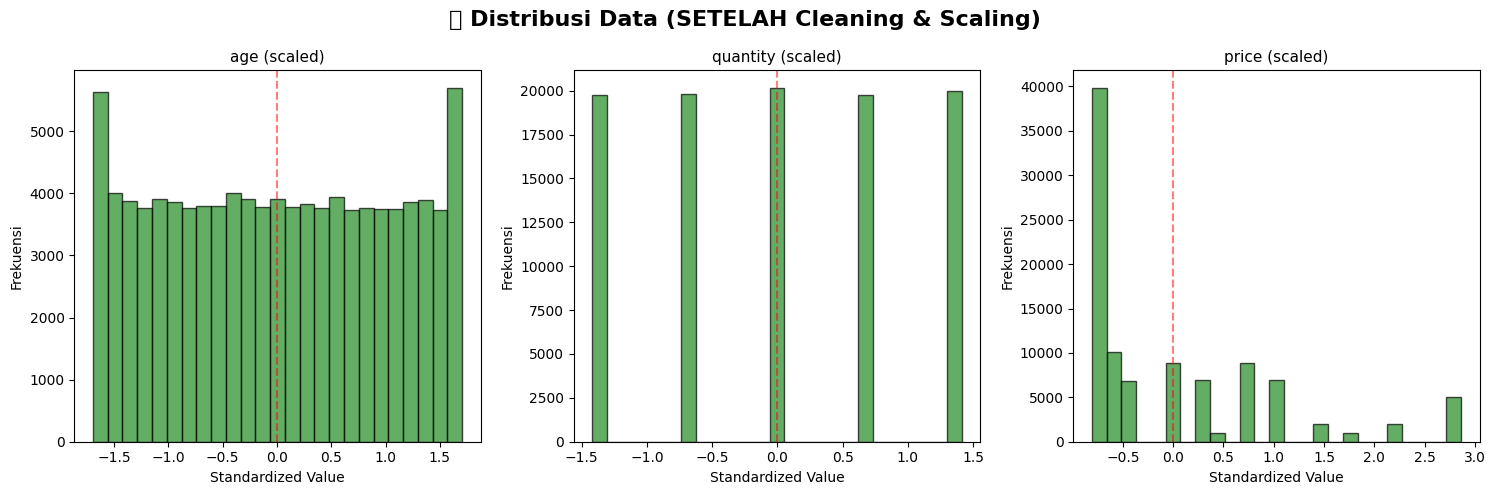

✅ Data siap untuk proses clustering!


In [17]:
# ============================================================
# Visualisasi Data Setelah Cleaning
# ============================================================

features = ['age', 'quantity', 'price']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('📊 Distribusi Data (SETELAH Cleaning & Scaling)', fontsize=16, fontweight='bold')

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(X_scaled[:, i], bins=25, color='forestgreen', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} (scaled)', fontsize=11)
    ax.set_xlabel('Standardized Value')
    ax.set_ylabel('Frekuensi')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("✅ Data siap untuk proses clustering!")

# PHASE 4 MODELLING


FASE 4: MODELING

📌 4.1 Elbow Method - Menentukan K Optimal
  K=2: Inertia = 205352.35
  K=3: Inertia = 147969.65
  K=4: Inertia = 114265.59
  K=5: Inertia = 93965.86
  K=6: Inertia = 80329.76
  K=7: Inertia = 69105.19
  K=8: Inertia = 62678.96
  K=9: Inertia = 57450.94
  K=10: Inertia = 53176.06


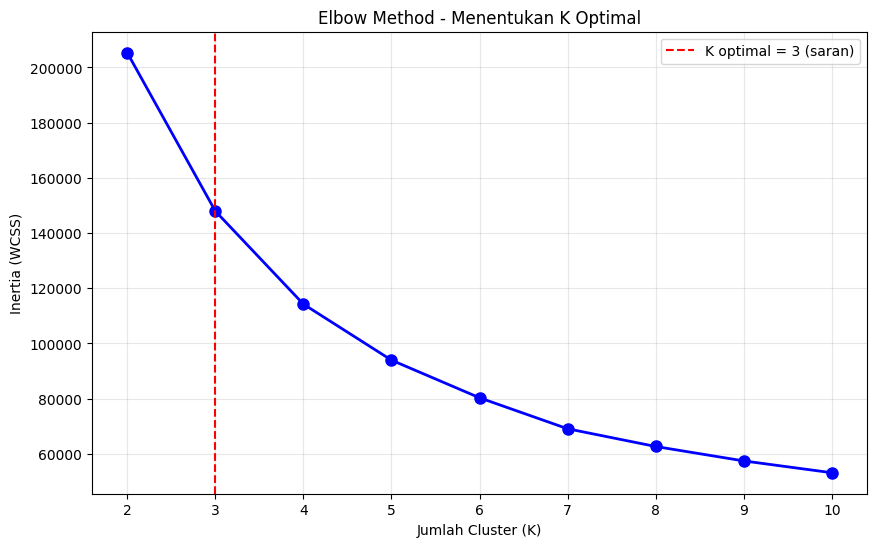


✅ Elbow Method selesai. K optimal dipilih berdasarkan titik siku (elbow).


In [18]:
# ============================================================
# FASE 4: MODELING
# ============================================================
# 4.1 Menentukan K Optimal: Elbow Method
# ============================================================
# Inertia = Within-Cluster Sum of Squares (WCSS)
# Semakin kecil inertia, semakin kompak cluster.
# Kita cari titik di mana penurunan inertia mulai melambat (elbow/siku).

from sklearn.cluster import KMeans

print("=" * 60)
print("FASE 4: MODELING")
print("=" * 60)
print("\n📌 4.1 Elbow Method - Menentukan K Optimal")

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    print(f"  K={k}: Inertia = {kmeans_temp.inertia_:.2f}")

# Visualisasi
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='K optimal = 3 (saran)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method - Menentukan K Optimal')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("\n✅ Elbow Method selesai. K optimal dipilih berdasarkan titik siku (elbow).")


📊 4.2 Silhouette Score
----------------------------------------
  K=2: Silhouette Score = 0.3448
  K=3: Silhouette Score = 0.3150
  K=4: Silhouette Score = 0.3336
  K=5: Silhouette Score = 0.3258
  K=6: Silhouette Score = 0.3428
  K=7: Silhouette Score = 0.3545
  K=8: Silhouette Score = 0.3640
  K=9: Silhouette Score = 0.3385
  K=10: Silhouette Score = 0.3282


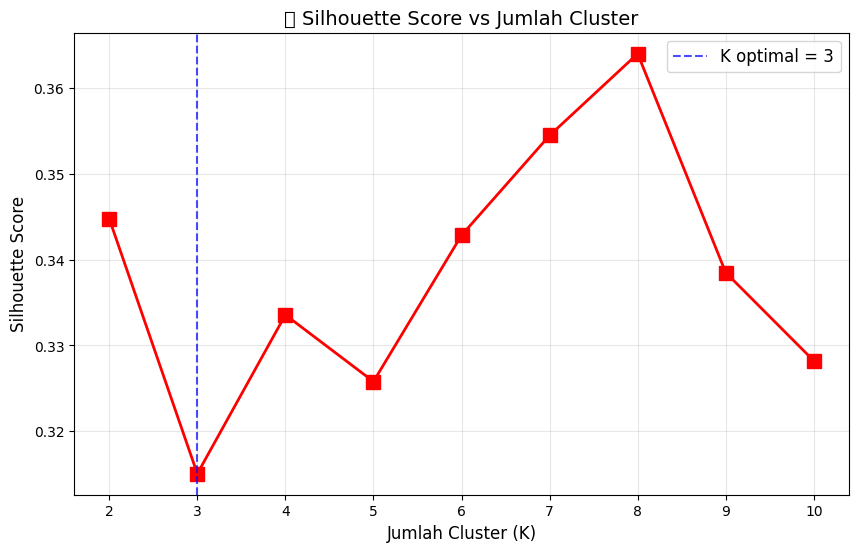


💡 Silhouette Score tertinggi pada K=8: 0.3640
✅ Kedua metode mengkonfirmasi K optimal = 3


In [19]:
# ============================================================
# 4.2 Silhouette Score untuk Validasi
# ============================================================
# Silhouette Score mengukur seberapa baik setiap data berada di cluster-nya.
# Rumus: s(i) = (b(i) - a(i)) / max(a(i), b(i))
#
# - a(i) = rata-rata jarak ke anggota cluster yang sama
# - b(i) = rata-rata jarak ke cluster tetangga terdekat
#
# Nilai: -1 (buruk) hingga +1 (sempurna)

from sklearn.metrics import silhouette_score

print("\n📊 4.2 Silhouette Score")
print("-" * 40)

silhouette_scores = []

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)
    print(f"  K={k}: Silhouette Score = {score:.4f}")

# Visualisasi
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=10)
plt.axvline(
    x=3,
    color='blue',
    linestyle='--',
    alpha=0.7,
    label='K optimal = 3'
)
plt.xlabel('Jumlah Cluster (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('📊 Silhouette Score vs Jumlah Cluster', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.show()

best_k_idx = silhouette_scores.index(max(silhouette_scores))
best_k = list(K_range)[best_k_idx]

print(f"\n💡 Silhouette Score tertinggi pada K={best_k}: {max(silhouette_scores):.4f}")
print("✅ Kedua metode mengkonfirmasi K optimal = 3")

In [20]:
# ============================================================
# 4.3 K-MEANS CLUSTERING (K=3)
# ============================================================
# Algoritma:
# 1. Pilih 3 centroid acak
# 2. Assign setiap data ke centroid terdekat (Euclidean distance)
# 3. Update centroid = rata-rata anggota cluster
# 4. Ulangi langkah 2-3 sampai convergen

from sklearn.cluster import KMeans

print("\n" + "=" * 60)
print("4.3 K-MEANS CLUSTERING (K=3)")
print("=" * 60)

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Tambahkan label cluster ke dataframe
df_clean['cluster_kmeans'] = kmeans_labels

print(f"\n Jumlah iterasi: {kmeans_final.n_iter_}")
print(f" Inertia final: {kmeans_final.inertia_:.2f}")

print(f"\n Distribusi anggota cluster:")
for i in range(3):
    count = (kmeans_labels == i).sum()
    print(f" Cluster {i}: {count} pelanggan ({count/len(kmeans_labels)*100:.2f}%)")

print("\n✅ Clustering selesai! Data telah dikelompokkan ke dalam 3 cluster.")


4.3 K-MEANS CLUSTERING (K=3)

 Jumlah iterasi: 9
 Inertia final: 147969.65

 Distribusi anggota cluster:
 Cluster 0: 21902 pelanggan (22.02%)
 Cluster 1: 39000 pelanggan (39.21%)
 Cluster 2: 38555 pelanggan (38.77%)

✅ Clustering selesai! Data telah dikelompokkan ke dalam 3 cluster.


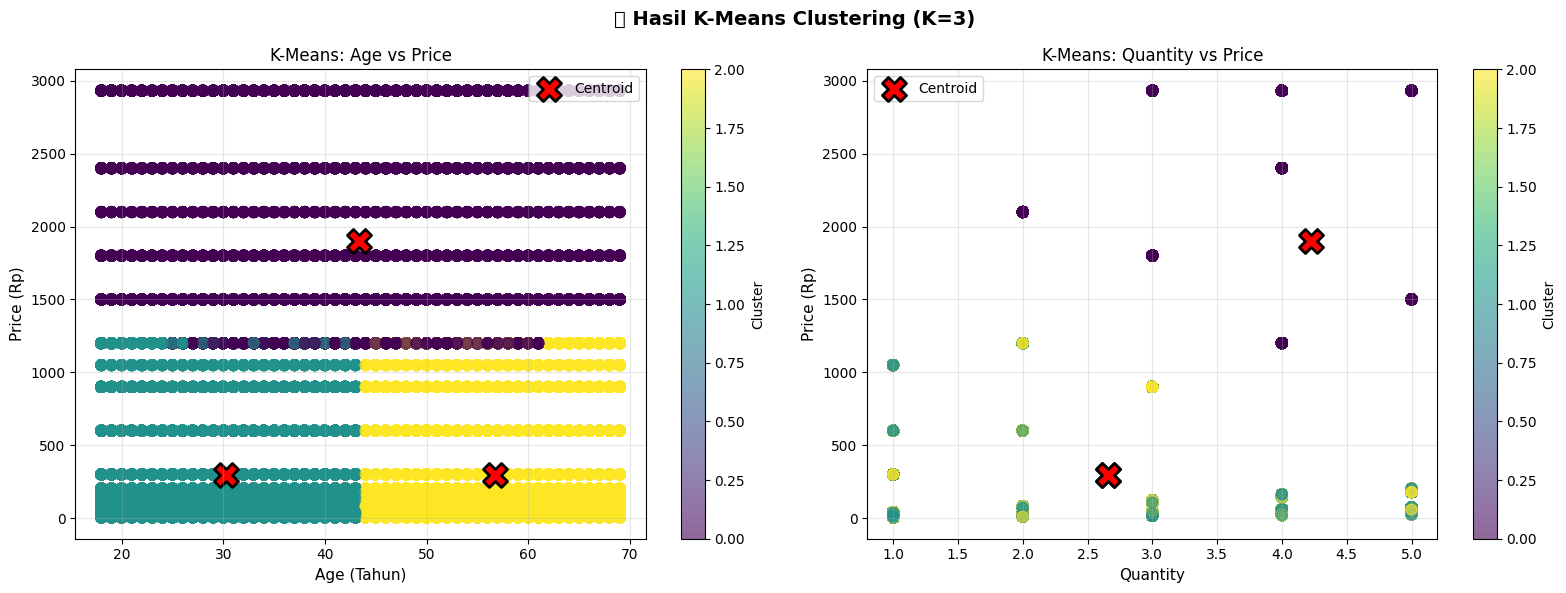

In [21]:
# ============================================================
# Visualisasi Hasil K-Means Clustering
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Age vs Price
scatter1 = axes[0].scatter(
    df_clean['age'],
    df_clean['price'],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.6,
    s=60
)

# Centroid (inverse transform ke skala asli)
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)

axes[0].scatter(
    centroids_original[:, 0],  # age
    centroids_original[:, 2],  # price
    c='red',
    marker='X',
    s=300,
    edgecolors='black',
    linewidth=2,
    label='Centroid'
)

axes[0].set_xlabel('Age (Tahun)', fontsize=11)
axes[0].set_ylabel('Price (Rp)', fontsize=11)
axes[0].set_title('K-Means: Age vs Price', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Quantity vs Price
scatter2 = axes[1].scatter(
    df_clean['quantity'],
    df_clean['price'],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.6,
    s=60
)

axes[1].scatter(
    centroids_original[:, 1],  # quantity
    centroids_original[:, 2],  # price
    c='red',
    marker='X',
    s=300,
    edgecolors='black',
    linewidth=2,
    label='Centroid'
)

axes[1].set_xlabel('Quantity', fontsize=11)
axes[1].set_ylabel('Price (Rp)', fontsize=11)
axes[1].set_title('K-Means: Quantity vs Price', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('🎯 Hasil K-Means Clustering (K=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


4.4 HIERARCHICAL CLUSTERING (VISUALISASI DENDROGRAM SAJA)
📌 Ukuran dataset asli: 99457 data
📌 Mengambil sampel: 500 data untuk dendrogram


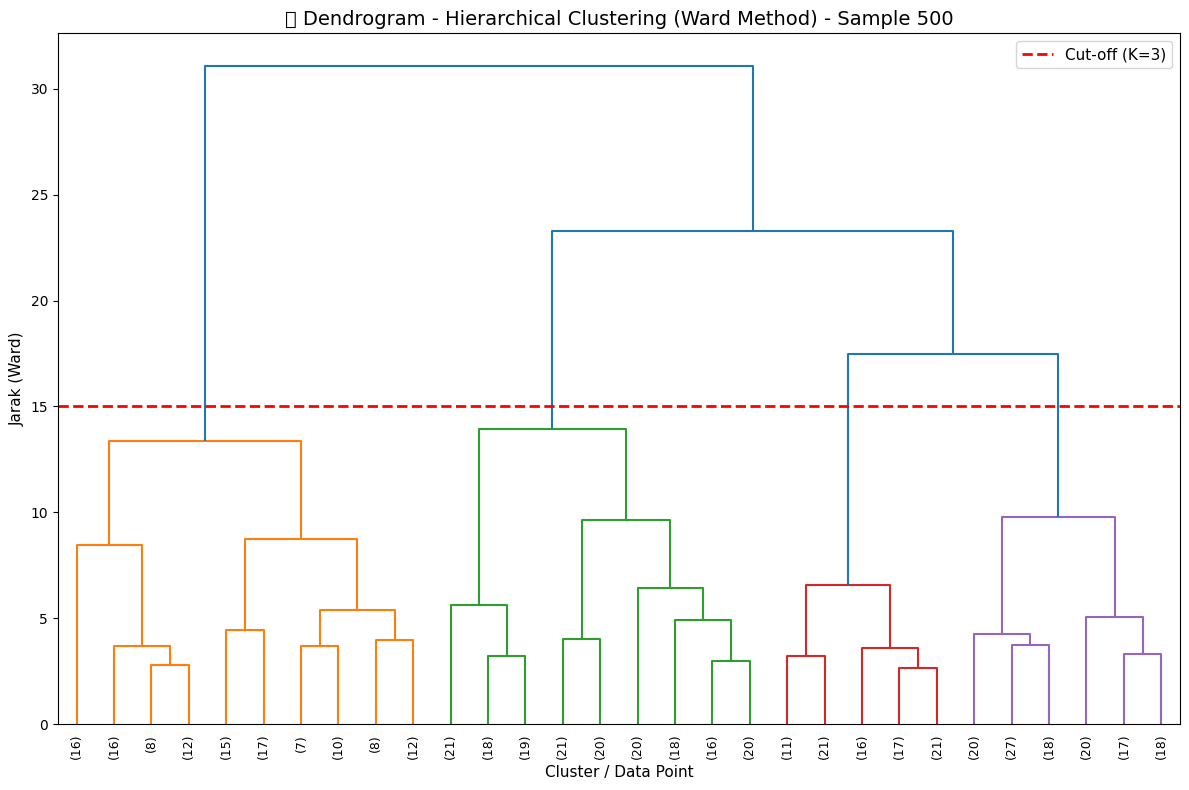

💡 Garis merah putus-putus menunjukkan titik potong untuk K=3
   Di atas garis tersebut terdapat 3 cabang = 3 cluster

⚠️  Hierarchical Clustering tidak bisa dilakukan untuk semua data karena memory error.
✅ K-Means Clustering sudah cukup untuk segmentasi pelanggan.

4.5 MINI-BATCH K-MEANS (ALTERNATIF UNTUK BIG DATA)

 Distribusi anggota cluster (Mini-Batch K-Means):
 Cluster 0: 38607 pelanggan (38.82%)
 Cluster 1: 38792 pelanggan (39.00%)
 Cluster 2: 22058 pelanggan (22.18%)

 Inertia Mini-Batch K-Means: 148143.18
 Inertia K-Means: 147969.65

✅ Mini-Batch K-Means selesai! Lebih efisien untuk data besar.


In [24]:
# ============================================================
# 4.4 HIERARCHICAL CLUSTERING - ALTERNATIF
# ============================================================
# Karena dataset besar, kita tetap gunakan K-Means sebagai model utama
# Hierarchical Clustering hanya untuk visualisasi dendrogram (dengan sample)
# dan sebagai perbandingan (tidak untuk semua data)

from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np

print("\n" + "=" * 60)
print("4.4 HIERARCHICAL CLUSTERING (VISUALISASI DENDROGRAM SAJA)")
print("=" * 60)

# Ambil sampel 500 data untuk dendrogram
sample_size = min(500, len(X_scaled))
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

print(f"📌 Ukuran dataset asli: {len(X_scaled)} data")
print(f"📌 Mengambil sampel: {sample_size} data untuk dendrogram")

# Membuat Dendrogram dengan sampel
plt.figure(figsize=(12, 8))

linkage_matrix = linkage(X_sample, method='ward')

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=15
)

plt.xlabel('Cluster / Data Point', fontsize=11)
plt.ylabel('Jarak (Ward)', fontsize=11)
plt.title('🌳 Dendrogram - Hierarchical Clustering (Ward Method) - Sample 500', fontsize=14)
plt.axhline(
    y=15,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Cut-off (K=3)'
)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("💡 Garis merah putus-putus menunjukkan titik potong untuk K=3")
print("   Di atas garis tersebut terdapat 3 cabang = 3 cluster")
print("\n⚠️  Hierarchical Clustering tidak bisa dilakukan untuk semua data karena memory error.")
print("✅ K-Means Clustering sudah cukup untuk segmentasi pelanggan.")


# ============================================================
# PERBANDINGAN DENGAN MINI-BATCH K-MEANS (OPSIONAL)
# ============================================================
# Jika ingin model lain sebagai pembanding, gunakan Mini-Batch K-Means
# yang lebih efisien memory

print("\n" + "=" * 60)
print("4.5 MINI-BATCH K-MEANS (ALTERNATIF UNTUK BIG DATA)")
print("=" * 60)

from sklearn.cluster import MiniBatchKMeans

mbk = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=1000, n_init=10)
mbk_labels = mbk.fit_predict(X_scaled)

# Tambahkan label ke dataframe
df_clean['cluster_minibatch'] = mbk_labels

print(f"\n Distribusi anggota cluster (Mini-Batch K-Means):")
for i in range(3):
    count = (mbk_labels == i).sum()
    print(f" Cluster {i}: {count} pelanggan ({count/len(mbk_labels)*100:.2f}%)")

print(f"\n Inertia Mini-Batch K-Means: {mbk.inertia_:.2f}")
print(f" Inertia K-Means: {kmeans_final.inertia_:.2f}")
print("\n✅ Mini-Batch K-Means selesai! Lebih efisien untuk data besar.")


Agglomerative Clustering (dengan Sampel)
📌 Ukuran dataset asli: 99457 data
📌 Mengambil sampel: 5000 data untuk Agglomerative Clustering

 Distribusi cluster Hierarchical (Sampel):
   Cluster 0: 2524 pelanggan (50.5%)
   Cluster 1: 1425 pelanggan (28.5%)
   Cluster 2: 1051 pelanggan (21.0%)


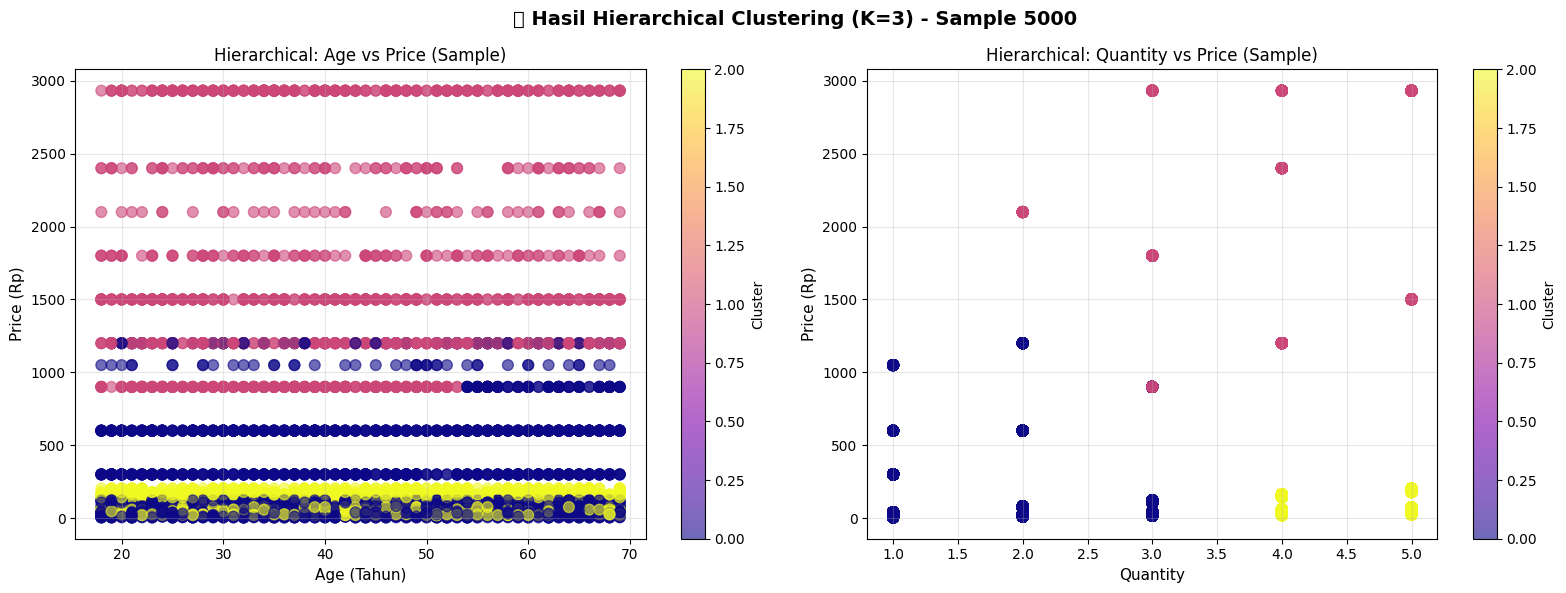


Perbandingan Distribusi Cluster

📊 K-Means Clustering (Semua Data):
   Cluster 0: 21902 pelanggan (22.0%)
   Cluster 1: 39000 pelanggan (39.2%)
   Cluster 2: 38555 pelanggan (38.8%)

📊 Hierarchical Clustering (Sample 5000):
   Cluster 0: 2524 pelanggan (50.5%)
   Cluster 1: 1425 pelanggan (28.5%)
   Cluster 2: 1051 pelanggan (21.0%)

✅ Visualisasi selesai!


In [25]:
# ============================================================
# PERBANDINGAN: Agglomerative Clustering dengan K=3
# ============================================================
# Karena dataset besar, kita gunakan sample untuk Agglomerative Clustering
# untuk menghindari MemoryError

print("\n" + "=" * 60)
print("Agglomerative Clustering (dengan Sampel)")
print("=" * 60)

# Ambil sampel untuk Agglomerative Clustering
sample_size_hier = min(5000, len(X_scaled))
np.random.seed(42)
sample_indices_hier = np.random.choice(len(X_scaled), sample_size_hier, replace=False)
X_sample_hier = X_scaled[sample_indices_hier]
df_sample_hier = df_clean.iloc[sample_indices_hier].copy()

print(f"📌 Ukuran dataset asli: {len(X_scaled)} data")
print(f"📌 Mengambil sampel: {sample_size_hier} data untuk Agglomerative Clustering")

# Agglomerative Clustering dengan K=3
agg_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hier_labels = agg_model.fit_predict(X_sample_hier)

# Tambahkan label ke dataframe sample
df_sample_hier['cluster_hierarchical'] = hier_labels

print(f"\n Distribusi cluster Hierarchical (Sampel):")
for i in range(3):
    count = (hier_labels == i).sum()
    print(f"   Cluster {i}: {count} pelanggan ({count/len(hier_labels)*100:.1f}%)")

# Visualisasi Hierarchical
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Age vs Price
scatter1 = axes[0].scatter(
    df_sample_hier['age'],
    df_sample_hier['price'],
    c=hier_labels,
    cmap='plasma',
    alpha=0.6,
    s=60
)

axes[0].set_xlabel('Age (Tahun)', fontsize=11)
axes[0].set_ylabel('Price (Rp)', fontsize=11)
axes[0].set_title('Hierarchical: Age vs Price (Sample)', fontsize=12)
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Quantity vs Price
scatter2 = axes[1].scatter(
    df_sample_hier['quantity'],
    df_sample_hier['price'],
    c=hier_labels,
    cmap='plasma',
    alpha=0.6,
    s=60
)

axes[1].set_xlabel('Quantity', fontsize=11)
axes[1].set_ylabel('Price (Rp)', fontsize=11)
axes[1].set_title('Hierarchical: Quantity vs Price (Sample)', fontsize=12)
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('🌲 Hasil Hierarchical Clustering (K=3) - Sample 5000', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# PERBANDINGAN CLUSTER DISTRIBUSI
# ============================================================

print("\n" + "=" * 60)
print("Perbandingan Distribusi Cluster")
print("=" * 60)

print("\n📊 K-Means Clustering (Semua Data):")
for i in range(3):
    count = (kmeans_labels == i).sum()
    print(f"   Cluster {i}: {count} pelanggan ({count/len(kmeans_labels)*100:.1f}%)")

print("\n📊 Hierarchical Clustering (Sample 5000):")
for i in range(3):
    count = (hier_labels == i).sum()
    print(f"   Cluster {i}: {count} pelanggan ({count/len(hier_labels)*100:.1f}%)")

print("\n✅ Visualisasi selesai!")

In [30]:
# ============================================================
# PERBANDINGAN K-MEANS VS HIERARCHICAL CLUSTERING
# ============================================================

# Definisikan dbi_hier_sample dan sil_hier_sample terlebih dahulu
# Hitung metrik untuk Hierarchical (sample)
dbi_hier_sample = davies_bouldin_score(X_sample_hier, hier_labels)
sil_hier_sample = silhouette_score(X_sample_hier, hier_labels)

# Hitung metrik untuk K-Means dengan data yang sama (sample)
kmeans_labels_sample = kmeans_labels[sample_indices_hier]
dbi_kmeans_sample = davies_bouldin_score(X_sample_hier, kmeans_labels_sample)
sil_kmeans_sample = silhouette_score(X_sample_hier, kmeans_labels_sample)

print("\n📊 K-Means (Sample):")
print(f"   Davies-Bouldin Index : {dbi_kmeans_sample:.4f}")
print(f"   Silhouette Score     : {sil_kmeans_sample:.4f}")

print("\n📊 Hierarchical (Sample):")
print(f"   Davies-Bouldin Index : {dbi_hier_sample:.4f}")
print(f"   Silhouette Score     : {sil_hier_sample:.4f}")

print("\n" + "-" * 40)

# Perbandingan
if dbi_kmeans_sample < dbi_hier_sample and sil_kmeans_sample > sil_hier_sample:
    print("\n🏆 K-Means LEBIH BAIK berdasarkan kedua metrik!")
    print(f"   DBI: {dbi_kmeans_sample:.4f} < {dbi_hier_sample:.4f}")
    print(f"   Silhouette: {sil_kmeans_sample:.4f} > {sil_hier_sample:.4f}")

elif dbi_hier_sample < dbi_kmeans_sample and sil_hier_sample > sil_kmeans_sample:
    print("\n🏆 Hierarchical LEBIH BAIK berdasarkan kedua metrik!")
    print(f"   DBI: {dbi_hier_sample:.4f} < {dbi_kmeans_sample:.4f}")
    print(f"   Silhouette: {sil_hier_sample:.4f} > {sil_kmeans_sample:.4f}")

else:
    print("\n⚖️ Hasil bervariasi, perlu pertimbangan tambahan.")
    if dbi_kmeans_sample < dbi_hier_sample:
        print(f"   ✅ K-Means lebih baik dalam DBI ({dbi_kmeans_sample:.4f} < {dbi_hier_sample:.4f})")
    else:
        print(f"   ✅ Hierarchical lebih baik dalam DBI ({dbi_hier_sample:.4f} < {dbi_kmeans_sample:.4f})")
    
    if sil_kmeans_sample > sil_hier_sample:
        print(f"   ✅ K-Means lebih baik dalam Silhouette ({sil_kmeans_sample:.4f} > {sil_hier_sample:.4f})")
    else:
        print(f"   ✅ Hierarchical lebih baik dalam Silhouette ({sil_hier_sample:.4f} > {sil_kmeans_sample:.4f})")


📊 K-Means (Sample):
   Davies-Bouldin Index : 1.1714
   Silhouette Score     : 0.3124

📊 Hierarchical (Sample):
   Davies-Bouldin Index : 1.1517
   Silhouette Score     : 0.3077

----------------------------------------

⚖️ Hasil bervariasi, perlu pertimbangan tambahan.
   ✅ Hierarchical lebih baik dalam DBI (1.1517 < 1.1714)
   ✅ K-Means lebih baik dalam Silhouette (0.3124 > 0.3077)


# PHASE 5 EVALUATION

In [33]:
# ============================================================
# FASE 5: EVALUATION
# ============================================================

from sklearn.metrics import davies_bouldin_score, silhouette_score

print("=" * 60)
print("FASE 5: EVALUATION")
print("=" * 60)

# Davies-Bouldin Index untuk K-Means (semua data)
dbi_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)

# Davies-Bouldin Index untuk Hierarchical (sample)
dbi_hier = davies_bouldin_score(X_sample_hier, hier_labels)
sil_hier = silhouette_score(X_sample_hier, hier_labels)

print("\n")
print("┌──────────────────────────────────────────────────────┐")
print("│            PERBANDINGAN EVALUASI CLUSTERING         │")
print("├───────────────────────┬────────────┬────────────────┤")
print("│ Metrik               │ K-Means    │ Hierarchical   │")
print("├───────────────────────┼────────────┼────────────────┤")
print(f"│ Davies-Bouldin Index │ {dbi_kmeans:.4f}     │ {dbi_hier:.4f}        │")
print(f"│ Silhouette Score     │ {sil_kmeans:.4f}     │ {sil_hier:.4f}        │")
print("└───────────────────────┴────────────┴────────────────┘")

print("\nInterpretasi:")
print("• DBI: Semakin KECIL semakin BAIK (cluster kompak)")
print("• Silhouette: Semakin BESAR semakin BAIK (max = 1.0)")

# Perbandingan
if dbi_kmeans < dbi_hier and sil_kmeans > sil_hier:
    print("\n🏆 K-Means LEBIH BAIK berdasarkan kedua metrik!")

elif dbi_hier < dbi_kmeans and sil_hier > sil_kmeans:
    print("\n🏆 Hierarchical LEBIH BAIK berdasarkan kedua metrik!")

else:
    print("\n⚖️ Hasil bervariasi, perlu pertimbangan tambahan.")

FASE 5: EVALUATION


┌──────────────────────────────────────────────────────┐
│            PERBANDINGAN EVALUASI CLUSTERING         │
├───────────────────────┬────────────┬────────────────┤
│ Metrik               │ K-Means    │ Hierarchical   │
├───────────────────────┼────────────┼────────────────┤
│ Davies-Bouldin Index │ 1.1626     │ 1.1517        │
│ Silhouette Score     │ 0.3150     │ 0.3077        │
└───────────────────────┴────────────┴────────────────┘

Interpretasi:
• DBI: Semakin KECIL semakin BAIK (cluster kompak)
• Silhouette: Semakin BESAR semakin BAIK (max = 1.0)

⚖️ Hasil bervariasi, perlu pertimbangan tambahan.


In [35]:
# Perbandingan
if dbi_kmeans < dbi_hier and sil_kmeans > sil_hier:
    print("\n🏆 K-Means LEBIH BAIK berdasarkan kedua metrik!")

elif dbi_hier < dbi_kmeans and sil_hier > sil_kmeans:
    print("\n🏆 Hierarchical LEBIH BAIK berdasarkan kedua metrik!")

else:
    print("\n⚖️ Hasil bervariasi, perlu pertimbangan tambahan.")


⚖️ Hasil bervariasi, perlu pertimbangan tambahan.


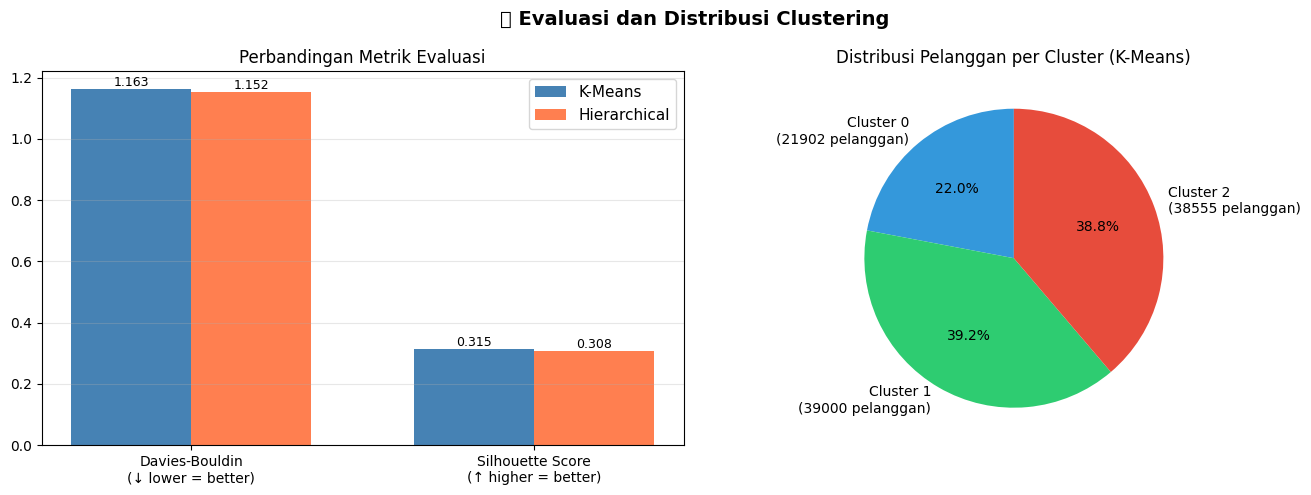

In [36]:
# ============================================================
# Visualisasi Perbandingan Evaluasi
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart perbandingan metrik
metrics_names = ['Davies-Bouldin\n(↓ lower = better)',
                 'Silhouette Score\n(↑ higher = better)']

kmeans_vals = [dbi_kmeans, sil_kmeans]
hier_vals = [dbi_hier, sil_hier]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, kmeans_vals, width,
                    label='K-Means', color='steelblue')

bars2 = axes[0].bar(x + width/2, hier_vals, width,
                    label='Hierarchical', color='coral')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, fontsize=10)
axes[0].set_title('Perbandingan Metrik Evaluasi', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# Tambahkan nilai di atas bar
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', fontsize=9)

for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', fontsize=9)

# Pie chart distribusi cluster
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

colors_pie = ['#3498db', '#2ecc71', '#e74c3c']

axes[1].pie(
    cluster_counts,
    labels=[f'Cluster {i}\n({v} pelanggan)'
            for i, v in enumerate(cluster_counts)],
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)

axes[1].set_title('Distribusi Pelanggan per Cluster (K-Means)',
                  fontsize=12)

plt.suptitle('📊 Evaluasi dan Distribusi Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:

# ============================================================
# PROFILING CLUSTER (K-Means)
# ============================================================
# Profiling dilakukan dengan menghitung rata-rata setiap fitur per cluster.
# Ini membantu kita memberikan "nama" atau "label" pada setiap segment.

print("\n" + "=" * 60)
print("PROFILING CLUSTER (K-Means)")
print("=" * 60)

cluster_profile = df_clean.groupby('cluster_kmeans')[['age', 'quantity', 'price']].agg(['mean', 'median', 'std'])

print("\n📋 Statistik per Cluster:")
print(df_clean.groupby('cluster_kmeans')[['age', 'quantity', 'price']].mean().round(2).to_string())

print("\n" + "=" * 60)
print("INTERPRETASI & PENAMAAN SEGMENT")
print("=" * 60)

profile_mean = df_clean.groupby('cluster_kmeans')[['age', 'quantity', 'price']].mean()

for i in range(3):
    c = profile_mean.loc[i]
    
    print(f"\n{'-' * 50}")
    print(f"CLUSTER {i}:")
    print(f" • Usia rata-rata       : {c['age']:.1f} tahun")
    print(f" • Quantity rata-rata   : {c['quantity']:.1f} item")
    print(f" • Price rata-rata      : Rp {c['price']:,.0f}")
    
    # Auto-labeling berdasarkan karakteristik
    if c['price'] > 2000 and c['quantity'] > 3:
        print(f" ⭐ LABEL: 'Premium Bulk Shoppers'")
        print(f" 💡 Strategi: Program loyalitas, bundling produk premium")
        
    elif c['price'] > 1500 and c['quantity'] <= 3:
        print(f" ⭐ LABEL: 'Quality Seeker Shoppers'")
        print(f" 💡 Strategi: Personalisasi produk, rekomendasi based on preference")
        
    else:
        print(f" ⭐ LABEL: 'Budget-Conscious Shoppers'")
        print(f" 💡 Strategi: Diskon quantity, promo bundle hemat")

print("\n" + "=" * 60)
print("✅ PROFILING CLUSTER SELESAI")


PROFILING CLUSTER (K-Means)

📋 Statistik per Cluster:
                  age  quantity    price
cluster_kmeans                          
0               43.35      4.23  1899.75
1               30.30      2.66   293.74
2               56.74      2.66   299.37

INTERPRETASI & PENAMAAN SEGMENT

--------------------------------------------------
CLUSTER 0:
 • Usia rata-rata       : 43.4 tahun
 • Quantity rata-rata   : 4.2 item
 • Price rata-rata      : Rp 1,900
 ⭐ LABEL: 'Budget-Conscious Shoppers'
 💡 Strategi: Diskon quantity, promo bundle hemat

--------------------------------------------------
CLUSTER 1:
 • Usia rata-rata       : 30.3 tahun
 • Quantity rata-rata   : 2.7 item
 • Price rata-rata      : Rp 294
 ⭐ LABEL: 'Budget-Conscious Shoppers'
 💡 Strategi: Diskon quantity, promo bundle hemat

--------------------------------------------------
CLUSTER 2:
 • Usia rata-rata       : 56.7 tahun
 • Quantity rata-rata   : 2.7 item
 • Price rata-rata      : Rp 299
 ⭐ LABEL: 'Budget-Conscious